In [161]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

df = pd.read_csv('../../Our Datasets/features_sample_match_new.csv')

start_types_wants = ['pass_interception', 'recovery']

df = df[df['start_type'].isin(start_types_wants)]

df['is_drawing'] = np.where(df['game_state'] == 'drawing', 1, 0)

df['is_middle_third'] = np.where(df['third_start'] == 'middle', 1, 0)

df = df.loc[df['team_out_of_possession_phase_type'] != 'defending_direct']

df['team_out_of_possession_phase_type'] = (
    df['team_out_of_possession_phase_type']
        .replace({
            'defending_set_play': 'set_play',
            'defending_quick_break': 'transition/quick_break',
            'defending_transition': 'transition/quick_break',
            'chaotic': 'chaotic/disruption',
            'disruption': 'chaotic/disruption'
        })
)

df = df.loc[df['team_out_of_possession_phase_type'] != 'set_play']


# dropping irrelevant columns
cols_to_drop = ['start_type', 'end_type', 'error', 
                'dist_to_near_goal', 'dist_to_far_goal', 'third_end', 'game_state', 'n_passing_options_dangerous_not_difficult', 'third_start',
                'n_forward_options', 'd_nearest_opp', 'd_nearest_team', 'mean_team_dist', 'n_opp_within5', 'max_player_targeted_xthreat']

df = df.drop(columns=cols_to_drop)

target_col = "player_targeted_dangerous"
df = df[df[target_col].notna()]

df = df.drop_duplicates(subset=['match_id', 'frame_start', 'frame_end'])

og_df = df.copy()

og_df["row_index"] = og_df.index

classifiers_cols_to_drop = ['Unique ID', 'event_index', 'frame_start', 'frame_end', 'event_row_index', 'source_file', 'rec_player_id', 
                            'rec_team_short', 'rec_team_id', 'prev_player_name', 'prev_player_id']

df = df.drop(columns=classifiers_cols_to_drop)


In [162]:
df = pd.get_dummies(df, columns=["team_out_of_possession_phase_type"], prefix="oop_phase", drop_first=False)

In [163]:
df['match_id'].unique()

array([1886347., 1899585., 1925299., 1953632., 1996435., 2006229.,
       2011166., 2013725., 2015213., 2017461.])

### Dangerous means if the probability of a goal being scored in the next 10 seconds (xthreat) is greater than 0.02

In [164]:
test_match_ids = [1886347, 1899585]

df_model = df.copy()
df_model["row_index"] = df_model.index

# Target
y = df_model["player_targeted_dangerous"].astype(int)

# Features
X = df_model.drop(columns=["player_targeted_dangerous"])

X.drop(columns=["row_index"], inplace=True)

# ---- Build mask from the original dataframe (safest) ----
is_test = df_model["match_id"].isin(test_match_ids)

# ---- Split ----
X_test  = X[is_test].copy()
y_test  = y[is_test].copy()
row_test = df_model.loc[is_test, "row_index"].copy()

X_train = X[~is_test].copy()
y_train = y[~is_test].copy()
row_train = df_model.loc[~is_test, "row_index"].copy()

# ---- NOW drop match_id from both splits ----
X_train = X_train.drop(columns=["match_id"])
X_test  = X_test.drop(columns=["match_id"])

total_rows = len(df_model)

print(f"Train rows: {len(X_train)}  ({len(X_train)/total_rows*100:.2f}%)")
print(f"Test rows : {len(X_test)}   ({len(X_test)/total_rows*100:.2f}%)")


Train rows: 540  (80.24%)
Test rows : 133   (19.76%)


In [165]:
X_test

,dist_to_attacking_goal,is_drawing,is_middle_third,oop_phase_chaotic/disruption,oop_phase_high_block,oop_phase_low_block,oop_phase_medium_block,oop_phase_transition/quick_break
0,99.824911,1,0,False,True,False,False,False
3,15.191136,1,0,True,False,False,False,False
14,53.789297,1,1,True,False,False,False,False
19,63.818283,1,1,True,False,False,False,False
20,80.062537,1,0,False,False,False,True,False
...,...,...,...,...,...,...,...,...
5357,87.777419,0,0,True,False,False,False,False
5359,56.524722,0,1,True,False,False,False,False
5362,43.008665,0,0,True,False,False,False,False
5365,76.978372,0,0,True,False,False,False,False


In [166]:
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [2, 5, 10],
    "max_features": [0.3, 0.5, 1]
}

rf_grid = GridSearchCV(
    rf_base,
    rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print("✅ Best RF Params:", rf_grid.best_params_)
print("✅ Best RF CV AUC:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_


Fitting 5 folds for each of 81 candidates, totalling 405 fits


✅ Best RF Params: {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 100}
✅ Best RF CV AUC: 0.7627413948992954


In [167]:
pos = y_train.sum()
neg = (y_train == 0).sum()
scale = neg / pos

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale,
    subsample=0.8
)

xgb_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [2, 3, 4, None],
    "learning_rate": [0.01, 0.05, .1],
    "min_child_weight": [5, 10, 20]
}

xgb_grid = GridSearchCV(
    xgb_base,
    xgb_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)


xgb_grid.fit(X_train, y_train)

print("✅ Best XGB Params:", xgb_grid.best_params_)
print("✅ Best XGB CV AUC:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_


Fitting 5 folds for each of 108 candidates, totalling 540 fits
✅ Best XGB Params: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 100}
✅ Best XGB CV AUC: 0.7705217816611585


In [168]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = [
    # L1 penalty
    {
        "clf__solver": ["liblinear", "saga"],
        "clf__penalty": ["l1"],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__max_iter": [200, 500, 1000]
    },

    # L2 penalty
    {
        "clf__solver": ["liblinear", "lbfgs", "saga"],
        "clf__penalty": ["l2"],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__max_iter": [200, 500, 1000]
    },

    # No regularization
    {
        "clf__solver": ["lbfgs", "newton-cg", "saga"],
        "clf__penalty": [None],
        "clf__max_iter": [200, 500, 1000]
    }
]

grid = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("✅ Best params:")
print(grid.best_params_)

print("✅ Best CV ROC-AUC:")
print(grid.best_score_)

best_log_reg = grid.best_estimator_


Fitting 5 folds for each of 69 candidates, totalling 345 fits
✅ Best params:
{'clf__C': 0.01, 'clf__max_iter': 200, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
✅ Best CV ROC-AUC:
0.7662749812932593


In [169]:
def evaluate_classifier(model, name):
    pred_test = model.predict(X_test)
    pred_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n📌 {name} Performance")
    print("Accuracy:", accuracy_score(y_test, pred_test))
    print("F1 Score:", f1_score(y_test, pred_test))
    print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
    print("\nClassification Report:\n", classification_report(y_test, pred_test))

evaluate_classifier(best_rf, "Random Forest Classifier")
evaluate_classifier(best_xgb, "XGBoost Classifier")
evaluate_classifier(best_log_reg, "Logistic Regression")


📌 Random Forest Classifier Performance
Accuracy: 0.7368421052631579
F1 Score: 0.6601941747572816
ROC-AUC: 0.7950904392764857

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.71      0.79        90
           1       0.57      0.79      0.66        43

    accuracy                           0.74       133
   macro avg       0.72      0.75      0.72       133
weighted avg       0.78      0.74      0.74       133


📌 XGBoost Classifier Performance
Accuracy: 0.7142857142857143
F1 Score: 0.6415094339622641
ROC-AUC: 0.8063307493540052

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.68      0.76        90
           1       0.54      0.79      0.64        43

    accuracy                           0.71       133
   macro avg       0.71      0.73      0.70       133
weighted avg       0.76      0.71      0.72       133


📌 Logistic Regression Performance
Accuracy: 0.759

In [170]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_gradient_bars(df, value_col, title, cmap="Blues"):
    """
    df: dataframe with 'feature' and value_col
    value_col: column with numeric values (importance, coef, etc.)
    cmap: any matplotlib colormap
    """
    df = df.sort_values(value_col, ascending=True)

    values = df[value_col].values
    features = df["feature"].values

    # Normalize values to [0,1]
    norm = (values - values.min()) / (values.max() - values.min() + 1e-9)

    # Create colors from colormap
    colors = plt.cm.get_cmap(cmap)(norm)

    plt.figure(figsize=(10, max(4, len(df) * 0.4)))
    plt.barh(features, values, color=colors)
    plt.title(title)
    plt.xlabel(value_col)
    plt.tight_layout()
    plt.show()


C:\Users\navee\AppData\Local\Temp\ipykernel_30860\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


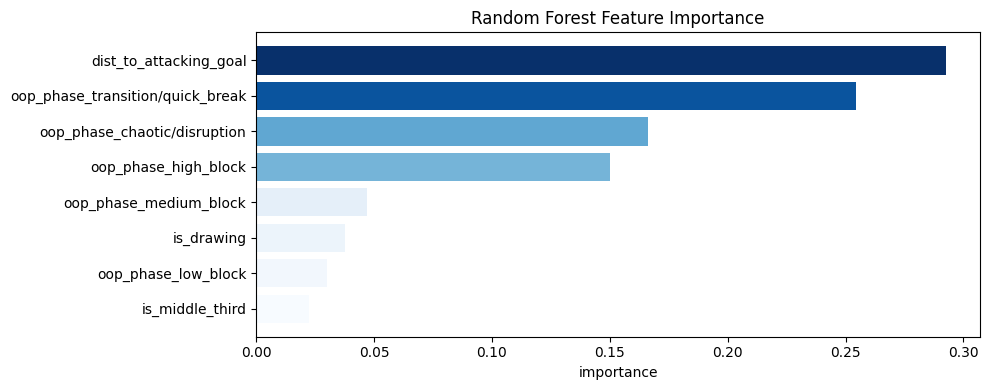

In [171]:
best_rf = rf_grid.best_estimator_

rf_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

plot_gradient_bars(rf_importance, "importance", "Random Forest Feature Importance", cmap="Blues")


C:\Users\navee\AppData\Local\Temp\ipykernel_30860\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


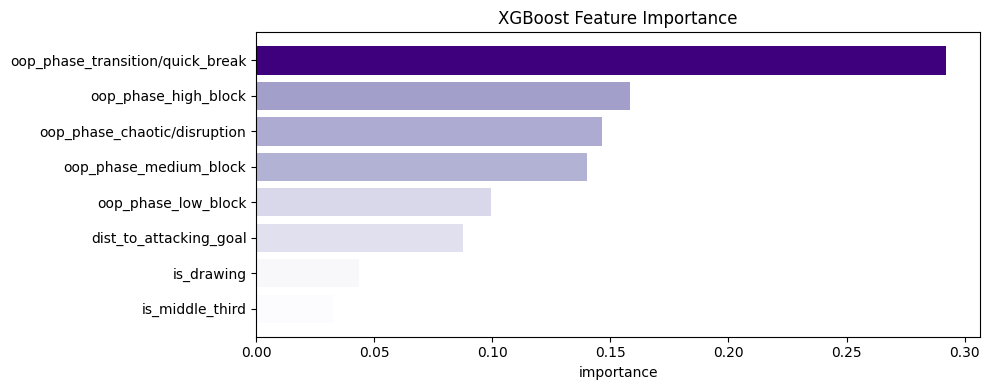

In [172]:
best_xgb = xgb_grid.best_estimator_

xgb_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

plot_gradient_bars(xgb_importance, "importance", "XGBoost Feature Importance", cmap="Purples")



C:\Users\navee\AppData\Local\Temp\ipykernel_30860\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


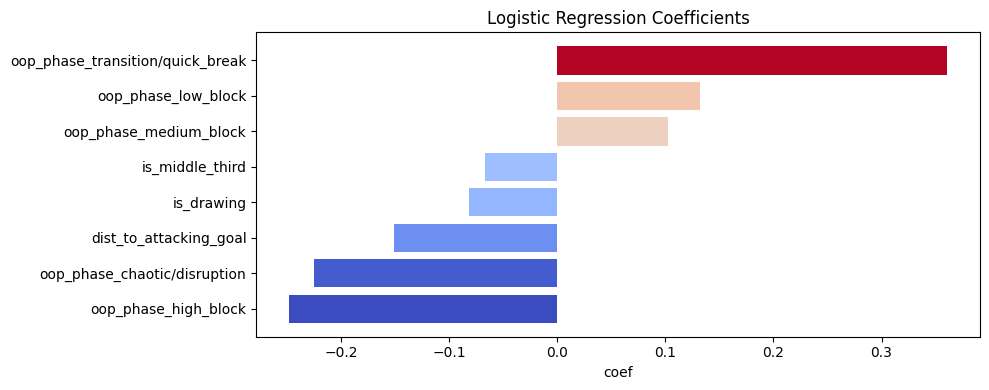

In [173]:
coefs = best_log_reg.named_steps["clf"].coef_[0]

logreg_importance = pd.DataFrame({
    "feature": X_test.columns,
    "coef": coefs
}).sort_values("coef", ascending=False)

plot_gradient_bars(
    logreg_importance,
    "coef",
    "Logistic Regression Coefficients",
    cmap="coolwarm"
)


In [174]:
X_test

,dist_to_attacking_goal,is_drawing,is_middle_third,oop_phase_chaotic/disruption,oop_phase_high_block,oop_phase_low_block,oop_phase_medium_block,oop_phase_transition/quick_break
0,99.824911,1,0,False,True,False,False,False
3,15.191136,1,0,True,False,False,False,False
14,53.789297,1,1,True,False,False,False,False
19,63.818283,1,1,True,False,False,False,False
20,80.062537,1,0,False,False,False,True,False
...,...,...,...,...,...,...,...,...
5357,87.777419,0,0,True,False,False,False,False
5359,56.524722,0,1,True,False,False,False,False
5362,43.008665,0,0,True,False,False,False,False
5365,76.978372,0,0,True,False,False,False,False


In [175]:
og_df

,Unique ID,match_id,event_index,frame_start,frame_end,rec_player_id,prev_player_id,prev_player_name,rec_team_short,rec_team_id,dist_to_attacking_goal,team_out_of_possession_phase_type,player_targeted_dangerous,event_row_index,source_file,is_drawing,is_middle_third,row_index
0,1886347_42_46,1886347.0,42.0,387.0,430.0,51009.0,965685.0,L. Gillion,Newcastle,1805.0,99.824911,high_block,0.0,0,1886347,1,0,0
3,1886347_170_193,1886347.0,170.0,1492.0,1492.0,966120.0,966120.0,B. Gibson,Newcastle,1805.0,15.191136,chaotic/disruption,0.0,3,1886347,1,0,3
14,1886347_452_466,1886347.0,452.0,3799.0,3799.0,795505.0,51667.0,D. Hall,Newcastle,1805.0,53.789297,chaotic/disruption,1.0,14,1886347,1,1,14
19,1886347_452_466,1886347.0,466.0,3854.0,3866.0,50951.0,50978.0,C. Timmins,Auckland FC,4177.0,63.818283,chaotic/disruption,1.0,19,1886347,1,1,19
20,1886347_536_558,1886347.0,536.0,4452.0,4452.0,735573.0,735573.0,T. Aquilina,Newcastle,1805.0,80.062537,medium_block,1.0,20,1886347,1,0,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5837,2017461_2727_2727,2017461.0,2727.0,49727.0,49741.0,23418.0,11117.0,Z. Machach,Auckland FC,4177.0,100.376725,chaotic/disruption,0.0,5837,2017461,1,0,5837
5838,2017461_2734_2734,2017461.0,2734.0,49759.0,49759.0,157294.0,23418.0,F. Gallegos,Melbourne V FC,868.0,42.199845,chaotic/disruption,0.0,5838,2017461,1,1,5838
5841,2017461_3125_3125,2017461.0,3125.0,55073.0,55073.0,14736.0,811820.0,K. Bos,Auckland FC,4177.0,46.775178,chaotic/disruption,0.0,5841,2017461,0,1,5841
5848,2017461_3660_3660,2017461.0,3660.0,63518.0,63527.0,43829.0,800322.0,J. Inserra,Auckland FC,4177.0,84.023016,chaotic/disruption,0.0,5848,2017461,0,0,5848


In [176]:
pred_class = best_log_reg.predict(X_test)
pred_prob = best_log_reg.predict_proba(X_test)[:, 1]

X_test_df = pd.DataFrame(X_test, index=X_test.index, columns=X.columns)

X_test_df = X_test_df.reset_index().rename(columns={'index':'row_index'})


# Build a results dataframe
results = pd.DataFrame({
    "row_index": row_test.values,
    "true_value": y_test.values,
    "predicted_class": pred_class,
    "predicted_probability": pred_prob
})

full_results = results.merge(
    og_df, 
    left_on="row_index", 
    right_on="row_index",
    how="inner"
)

full_results.to_csv('../../Our Datasets/classifier_results_logreg.csv', index=False)


In [177]:
full_results

,row_index,true_value,predicted_class,predicted_probability,Unique ID,match_id,event_index,frame_start,frame_end,rec_player_id,...,prev_player_name,rec_team_short,rec_team_id,dist_to_attacking_goal,team_out_of_possession_phase_type,player_targeted_dangerous,event_row_index,source_file,is_drawing,is_middle_third
0,0,0,0,0.261289,1886347_42_46,1886347.0,42.0,387.0,430.0,51009.0,...,L. Gillion,Newcastle,1805.0,99.824911,high_block,0.0,0,1886347,1,0
1,3,0,0,0.469147,1886347_170_193,1886347.0,170.0,1492.0,1492.0,966120.0,...,B. Gibson,Newcastle,1805.0,15.191136,chaotic/disruption,0.0,3,1886347,1,0
2,14,1,0,0.367992,1886347_452_466,1886347.0,452.0,3799.0,3799.0,795505.0,...,D. Hall,Newcastle,1805.0,53.789297,chaotic/disruption,1.0,14,1886347,1,1
3,19,1,0,0.351129,1886347_452_466,1886347.0,466.0,3854.0,3866.0,50951.0,...,C. Timmins,Auckland FC,4177.0,63.818283,chaotic/disruption,1.0,19,1886347,1,1
4,20,1,1,0.522681,1886347_536_558,1886347.0,536.0,4452.0,4452.0,735573.0,...,T. Aquilina,Newcastle,1805.0,80.062537,medium_block,1.0,20,1886347,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,5357,0,0,0.380565,1899585_3944_3944,1899585.0,3944.0,51294.0,51308.0,159938.0,...,H. Sakai,Wellington P FC,867.0,87.777419,chaotic/disruption,0.0,5357,1899585,0,0
129,5359,0,0,0.402681,1899585_4022_4022,1899585.0,4022.0,51826.0,51837.0,51667.0,...,S. Colakovski,Auckland FC,4177.0,56.524722,chaotic/disruption,0.0,5359,1899585,0,1
130,5362,0,0,0.460033,1899585_4066_4066,1899585.0,4066.0,52781.0,52781.0,133498.0,...,M. Sheridan,Auckland FC,4177.0,43.008665,chaotic/disruption,0.0,5362,1899585,0,0
131,5365,0,0,0.399323,1899585_4235_4235,1899585.0,4235.0,54418.0,54426.0,159938.0,...,G. May,Wellington P FC,867.0,76.978372,chaotic/disruption,0.0,5365,1899585,0,0
